# LATTE Overview — Cross-Task Aggregated Results

This notebook presents a high-level public summary of the LATTE system across three experimental domains: **simple_eda**, **debug_sprint**, and **textproc**. 

**Key plots included:**
- **Aggregated efficiency & accuracy** — Pareto scatter showing final accuracy vs. token cost across all trials
- **Coordination metrics** — Idleness, cross-agent consistency conflicts, message volume by condition
- **LATTE operator usage** — Task-graph growth and operator invocation patterns
- **Performance tables**

In [50]:
import json
import csv as _csv
import re as _re
from pathlib import Path
from collections import defaultdict as _dd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re, statistics, math
import networkx as nx

In [51]:
_ROOT = Path("..").resolve()

SOURCES = [
    ("experiments/experiment1/n4/results.csv", "simple_eda"),
    ("experiments/experiment2/n4/results.csv", "debug_sprint"),
    ("experiments/experiment3/n4/results.csv", "textproc"),
]

METAGPT_SOURCES = [
    ("experiments/experiment2/n4", "debug_sprint", "debug_sprint"),
    ("experiments/experiment2/n4", "search_lib",   "library_build"),
]

CONDITION_NORMALIZE = {"fixed": "static"}

CONDITION_EXCLUDE_METRICS = {"single_agent"}

CONDITION_COLORS = {
    "dynamic":       "#2196F3",
    "no_graph":      "#AB47BC",
    "decentralized": "#EF5350",
    "static":        "#4CAF50",
    "metagpt":       "#FF8F00",
}

TASK_ORDER = ["simple_eda", "debug_sprint", "textproc"]

print(f"Repo root: {_ROOT}")

Repo root: /Users/emieczkowski/Desktop/latte


In [52]:
def _parse_model_display(run_dir_str: str) -> str:
    """Extract a short provider/model label from a run_dir path."""
    stem = Path(run_dir_str).name
    stem = _re.sub(r'_\d{8}_\d{6}$', '', stem)
    stem = _re.sub(r'_(static|fixed|dynamic|decentralized|no_graph|single_agent|metagpt)$', '', stem)
    stem = _re.sub(r'_\d{2}$', '', stem)
    parts = stem.split('_', 1)
    return f"{parts[0]}/{parts[1]}" if len(parts) == 2 else stem


def load_all_runs(sources: list[tuple[str, str]], root: Path) -> list[dict]:
    """Load all results CSVs, tagging each row with the task label."""
    int_fields   = ["trial", "n_teammates", "tasks_done", "total_tasks",
                    "total_rounds", "total_input_tokens", "total_output_tokens",
                    "total_tokens", "dispatched_agent_rounds",
                    "possible_agent_rounds", "idle_agent_rounds"]
    float_fields = ["task_completion_rate", "wall_clock_seconds",
                    "tokens_per_task", "idle_fraction"]

    seen_run_dirs = set()
    rows = []
    for csv_rel, task_label in sources:
        csv_path = root / csv_rel
        if not csv_path.exists():
            print(f"  [skip] {csv_rel} — not found")
            continue
        n_loaded = 0
        with csv_path.open() as f:
            for row in _csv.DictReader(f):
                run_dir = row.get("run_dir", "")
                if run_dir in seen_run_dirs:
                    continue
                seen_run_dirs.add(run_dir)

                for k in int_fields:
                    try:
                        row[k] = int(float(row[k])) if row.get(k) not in (None, "") else 0
                    except (ValueError, TypeError):
                        row[k] = 0
                for k in float_fields:
                    try:
                        row[k] = float(row[k]) if row.get(k) not in (None, "") else 0.0
                    except (ValueError, TypeError):
                        row[k] = 0.0

                row["success"]   = str(row.get("success", "")).strip().lower() == "true"
                row["model"]     = _parse_model_display(row.get("run_dir", ""))
                row["task"]      = task_label
                row["condition"] = CONDITION_NORMALIZE.get(row["condition"], row["condition"])

                _TOKEN_TIME = ("total_tokens", "total_input_tokens", "total_output_tokens",
                               "tokens_per_task", "wall_clock_seconds")
                if row.get("total_tokens", 0) == 0:
                    for k in _TOKEN_TIME:
                        row[k] = None

                rows.append(row)
                n_loaded += 1
        print(f"  {csv_rel}: {n_loaded} rows → task={task_label}")
    return rows


def load_metagpt_sources(sources: list[tuple[str, str, str]], root: Path) -> list[dict]:
    """Load MetaGPT CSV-based runs."""
    MODEL_MAP = {"gpt52": "openai/gpt-5.2", "sonnet": "anthropic/claude-sonnet-4-6"}
    rows = []
    for dir_rel, task_prefix, task_label in sources:
        exp_dir  = root / dir_rel
        comp_p   = exp_dir / "completion_metagpt.csv"
        tok_p    = exp_dir / "tokens_metagpt.csv"
        wall_p   = exp_dir / "wallclock_metagpt.csv"

        completion, tokens, wallclock, role_counts = {}, {}, {}, _dd(int)

        if comp_p.exists():
            with comp_p.open() as f:
                for row in _csv.DictReader(f):
                    pct = float(row["pass_rate"].rstrip("%")) / 100.0
                    completion[row["run"]] = {
                        "passed": int(row["passed"]),
                        "total":  int(row["total"]),
                        "pass_rate": pct,
                    }
        if tok_p.exists():
            with tok_p.open() as f:
                for row in _csv.DictReader(f):
                    run = row["run"]
                    if row["role"] == "TOTAL":
                        tokens[run] = {
                            "total_input_tokens":  int(row["input_tokens"]),
                            "total_output_tokens": int(row["output_tokens"]),
                            "total_tokens":        int(row["total_tokens"]),
                        }
                    else:
                        role_counts[run] += 1
        if wall_p.exists():
            with wall_p.open() as f:
                for row in _csv.DictReader(f):
                    if row["role"] != "TOTAL":
                        continue
                    ws = row.get("wall_clock_s", "").strip()
                    ae = row.get("api_elapsed_s", "").strip()
                    wallclock[row["run"]] = float(ws) if ws else float(ae)

        for run in sorted(set(completion) | set(tokens) | set(wallclock)):
            m = _re.match(r'^(.+?)_(gpt52|sonnet)_r(\d+)$', run)
            if not m:
                continue
            task_key, model_key, trial_str = m.group(1), m.group(2), m.group(3)
            if not task_key.startswith(task_prefix):
                continue
            comp      = completion.get(run, {})
            tok       = tokens.get(run, {})
            wall_s    = wallclock.get(run)
            total_tok = tok.get("total_tokens")
            passed    = comp.get("passed")
            rows.append({
                "condition":            "metagpt",
                "trial":                int(trial_str),
                "n_teammates":          4,
                "success":              comp.get("pass_rate", 0.0) == 1.0,
                "tasks_done":           passed,
                "total_tasks":          comp.get("total"),
                "task_completion_rate": comp.get("pass_rate"),
                "wall_clock_seconds":   wall_s,
                "total_rounds":         None,
                "total_input_tokens":   tok.get("total_input_tokens"),
                "total_output_tokens":  tok.get("total_output_tokens"),
                "total_tokens":         total_tok,
                "tokens_per_task":      total_tok / passed if total_tok and passed else None,
                "idle_fraction":        None,
                "model":                MODEL_MAP.get(model_key, model_key),
                "task":                 task_label,
                "run_dir":              f"metagpt/{run}",
            })
        print(f"  metagpt CSVs in {dir_rel}: {sum(1 for r in rows if r.get('task')==task_label and r['condition']=='metagpt')} rows → task={task_label}")
    return rows

In [38]:
HIDDEN_SOURCES = [
    ("experiments/experiment1/n4/hidden_eval_results.csv", "simple_eda"),
    ("experiments/textproc/n4/hidden_eval_results.csv",   "textproc"),
]

def _model_from_hidden_csv(raw: str) -> str:
    parts = raw.split("_", 1)
    return f"{parts[0]}/{parts[1]}" if len(parts) == 2 else raw

def load_hidden_runs(sources: list[tuple[str, str]], root) -> list[dict]:
    rows = []
    for csv_rel, task_label in sources:
        csv_path = root / csv_rel
        if not csv_path.exists():
            print(f"  [skip] {csv_rel} — not found")
            continue
        import csv as _csv2
        n = 0
        with csv_path.open() as f:
            for row in _csv2.DictReader(f):
                try:
                    hpr = float(row["hidden_pass_rate"])
                except (KeyError, ValueError, TypeError):
                    hpr = None
                cond = CONDITION_NORMALIZE.get(row.get("condition", ""), row.get("condition", ""))
                rows.append({
                    "task":            task_label,
                    "model":           _model_from_hidden_csv(row.get("model", "")),
                    "condition":       cond,
                    "trial":           row.get("trial"),
                    "run_dir":         row.get("run_dir", ""),
                    "hidden_pass_rate": hpr,
                })
                n += 1
        print(f"  {csv_rel}: {n} rows → task={task_label}")
    return rows

In [53]:
tasks  = [t for t in TASK_ORDER if any(r["task"] == t for r in all_runs)]
conds  = sorted(set(r["condition"] for r in all_runs))
models = sorted(set(r["model"] for r in all_runs))

for task in tasks:
    task_runs = [r for r in all_runs if r["task"] == task]
    task_conds = sorted(set(r["condition"] for r in task_runs))
    task_models = sorted(set(r["model"] for r in task_runs))
    header = f"  {'condition':<16}" + "".join(f"{m.split('/')[-1]:>22}" for m in task_models) + f"  {'TOTAL':>10}"

    for cond in task_conds:
        row_str = f"  {cond:<16}"
        row_total_n = 0; row_total_s = 0
        for model in task_models:
            subset = [r for r in task_runs if r["condition"] == cond and r["model"] == model]
            n = len(subset)
            s = sum(1 for r in subset if r["success"])
            row_total_n += n; row_total_s += s
            cell = f"{s}/{n}" if n > 0 else "-"
            row_str += f"{cell:>22}"
        row_str += f"  {row_total_s}/{row_total_n:>6}"

    # Total row
    row_str = f"  {'TOTAL':<16}"
    for model in task_models:
        n = sum(1 for r in task_runs if r["model"] == model)
        s = sum(1 for r in task_runs if r["model"] == model and r["success"])
        row_str += f"{s}/{n:>20}"
    n = len(task_runs); s = sum(1 for r in task_runs if r["success"])
    row_str += f"  {s}/{n:>6}"

In [54]:
_HIDDEN_ACCURACY_TASKS = {"simple_eda", "textproc"}

def _sem(vals):
    a = np.array(vals, dtype=float)
    return np.nan if len(a) < 2 else np.std(a, ddof=1) / np.sqrt(len(a))

def _fmt_acc(vals):
    if not vals:
        return "—"
    m = np.mean(vals); s = _sem(vals)
    return (f"{m:.0%} ± {s:.0%}" if not np.isnan(s) else f"{m:.0%}")

def _fmt_tok(vals):
    if not vals:
        return "—"
    v = [x / 1_000 for x in vals]
    m = np.mean(v); s = _sem(v)
    return f"{m:.0f} ± {s:.0f}K" if not np.isnan(s) else f"{m:.0f}K"

def _fmt_wall(vals):
    if not vals:
        return "—"
    v = [x / 60 for x in vals]
    m = np.mean(v); s = _sem(v)
    return f"{m:.1f} ± {s:.1f}m" if not np.isnan(s) else f"{m:.1f}m"

def build_sem_table(runs, hidden_runs, tasks):
    _hmap = {}
    for r in hidden_runs:
        if r.get("hidden_pass_rate") is None:
            continue
        key = (r["task"], r["model"], r["condition"])
        _hmap.setdefault(key, []).append(r["hidden_pass_rate"])

    models = sorted(set(r["model"] for r in runs))
    conds  = sorted(set(r["condition"] for r in runs),
                    key=lambda c: list(CONDITION_COLORS).index(c)
                                  if c in CONDITION_COLORS else 99)
    def _build_rows(model_label, subset_runs, hmap_models):
        """Build one row per condition for a given model label and run subset."""
        out = []
        for cond in conds:
            s = [r for r in subset_runs if r["condition"] == cond]
            if not s:
                continue
            row = {"Model": model_label, "Condition": cond}
            all_acc, all_toks, all_wall = [], [], []
            for task in tasks:
                ts = [r for r in s if r["task"] == task]
                if task in _HIDDEN_ACCURACY_TASKS:
                    acc = []
                    for m in hmap_models:
                        acc.extend(_hmap.get((task, m, cond), []))
                else:
                    acc = [1.0 if r["success"] else 0.0 for r in ts]
                toks = [r["total_tokens"] for r in ts if r.get("total_tokens")]
                wall = [r["wall_clock_seconds"] for r in ts if r.get("wall_clock_seconds")]
                row[(task, "Accuracy")]   = _fmt_acc(acc)
                row[(task, "Tokens")]     = _fmt_tok(toks)
                row[(task, "Wall-clock")] = _fmt_wall(wall)
                all_acc.extend(acc)
                all_toks.extend(toks)
                all_wall.extend(wall)
            row[("Average", "Accuracy")]   = _fmt_acc(all_acc)
            row[("Average", "Tokens")]     = _fmt_tok(all_toks)
            row[("Average", "Wall-clock")] = _fmt_wall(all_wall)
            out.append(row)
        return out

    rows_data = []
    for model in models:
        rows_data.extend(_build_rows(model.split("/")[-1], [r for r in runs if r["model"] == model], [model]))

    _sep = {"Model": "─" * 20, "Condition": ""}
    for task in tasks:
        _sep[(task, "Accuracy")] = _sep[(task, "Tokens")] = _sep[(task, "Wall-clock")] = ""
    _sep[("Average", "Accuracy")] = _sep[("Average", "Tokens")] = _sep[("Average", "Wall-clock")] = ""
    rows_data.append(_sep)

    _claude_gpt_models = [m for m in models if m.split("/")[0] in ("anthropic", "openai")]
    _claude_gpt_runs   = [r for r in runs   if r["model"] in _claude_gpt_models]
    rows_data.extend(_build_rows("Claude+GPT (avg)", _claude_gpt_runs, _claude_gpt_models))

    df = pd.DataFrame(rows_data).set_index(["Model", "Condition"])
    df.columns = pd.MultiIndex.from_tuples(df.columns)
    return df

_sem_tasks = [t for t in TASK_ORDER if any(r["task"] == t for r in all_runs)]
_sem_df    = build_sem_table(all_runs, hidden_runs, _sem_tasks)

print("Accuracy: hidden eval pass rate for simple_eda/textproc; oracle pass rate elsewhere")
print("Tokens: all runs (K). Wall-clock: all runs (minutes).")
print("All values: mean ± 1 SEM\n")
pd.set_option("display.max_colwidth", 20)
pd.set_option("display.width", 200)
display(_sem_df)


Accuracy: hidden eval pass rate for simple_eda/textproc; oracle pass rate elsewhere
Tokens: all runs (K). Wall-clock: all runs (minutes).
All values: mean ± 1 SEM



simple_eda                          debug_sprint                            textproc                             Average                         
                                     Accuracy      Tokens   Wall-clock     Accuracy       Tokens   Wall-clock  Accuracy      Tokens   Wall-clock   Accuracy      Tokens   Wall-clock
Model                Condition                                                                                                                                                      
claude-sonnet-4-6    dynamic         99% ± 1%    92 ± 16K   3.2 ± 0.4m    100% ± 0%    162 ± 34K   5.8 ± 1.0m  36% ± 2%     94 ± 9K   2.3 ± 0.3m   81% ± 6%   117 ± 14K   3.8 ± 0.5m
                     no_graph        96% ± 1%   471 ± 72K   8.2 ± 1.0m    100% ± 0%    415 ± 54K   7.7 ± 0.8m  29% ± 3%   177 ± 21K   4.5 ± 0.4m   78% ± 6%   354 ± 38K   6.8 ± 0.5m
                     decentralized   98% ± 1%   518 ± 43K   5.1 ± 0.3m    100% ± 0%   699 ± 115K   5.9 ± 0.7m  28% ± 4%   202 ± 36K   3.0 ± 0.3m   76% ± 7%   473 ± 56K   4.7 ± 0.3m
                     static          93% ± 2%  596 ± 166K  12.2 ± 1.9m    60% ± 16%    253 ± 30K   5.7 ± 0.6m  34% ± 3%   148 ± 18K   4.0 ± 0.4m   61% ± 8%   333 ± 65K   7.3 ± 0.9m
                     metagpt         81% ± 1%   645 ± 43K  14.0 ± 0.7m    60% ± 16%    321 ± 78K  12.8 ± 2.7m  39% ± 5%  2092 ± 93K  43.7 ± 4.2m  63% ± 11%  629 ± 119K  16.3 ± 2.4m
gpt-5.2              dynamic         93% ± 1%   152 ± 17K   3.2 ± 0.3m    100% ± 0%    298 ± 51K   4.8 ± 0.7m  44% ± 2%   101 ± 15K   1.9 ± 0.2m   79% ± 5%   180 ± 23K   3.3 ± 0.3m
                     no_graph        92% ± 2%     44 ± 6K   1.6 ± 0.2m    80% ± 13%  1005 ± 160K  10.6 ± 2.2m  19% ± 2%   161 ± 26K   2.7 ± 0.4m   63% ± 7%   403 ± 95K   4.9 ± 1.0m
                     decentralized   88% ± 2%     24 ± 1K   0.8 ± 0.0m    100% ± 0%    886 ± 86K   6.3 ± 0.6m  27% ± 2%   186 ± 35K   1.4 ± 0.1m   72% ± 6%   365 ± 76K   2.8 ± 0.5m
                     static          84% ± 2%   210 ± 24K   4.5 ± 0.5m    17% ± 17%   536 ± 117K   7.1 ± 1.2m  46% ± 3%   132 ± 18K   2.9 ± 0.3m   54% ± 6%   255 ± 42K   4.5 ± 0.5m
                     metagpt         71% ± 3%   161 ± 13K   5.9 ± 0.5m      0% ± 0%     83 ± 14K   4.1 ± 0.7m   0% ± 0%   430 ± 25K  14.0 ± 0.5m   15% ± 6%   229 ± 30K   8.1 ± 0.9m
────────────────────                                                                                                                                                                
Claude+GPT (avg)     dynamic         96% ± 1%   122 ± 13K   3.2 ± 0.3m    100% ± 0%    227 ± 33K   5.3 ± 0.6m  40% ± 2%     98 ± 9K   2.1 ± 0.2m   80% ± 4%   148 ± 14K   3.5 ± 0.3m
                     no_graph        94% ± 1%   257 ± 60K   4.9 ± 0.9m     90% ± 7%   710 ± 106K   9.1 ± 1.2m  23% ± 2%   169 ± 17K   3.6 ± 0.3m   70% ± 5%   379 ± 51K   5.9 ± 0.6m
                     decentralized   93% ± 2%   271 ± 60K   2.9 ± 0.5m    100% ± 0%    792 ± 73K   6.1 ± 0.4m  27% ± 2%   194 ± 25K   2.2 ± 0.2m   74% ± 4%   419 ± 47K   3.7 ± 0.3m
                     static          88% ± 2%   403 ± 93K   8.3 ± 1.3m    44% ± 13%    359 ± 57K   6.2 ± 0.6m  40% ± 2%   140 ± 12K   3.4 ± 0.3m   58% ± 5%   297 ± 40K   6.0 ± 0.6m
                     metagpt         75% ± 2%   390 ± 61K   9.7 ± 1.0m    32% ± 11%    208 ± 49K   8.7 ± 1.7m   6% ± 4%  707 ± 188K  18.9 ± 3.4m   34% ± 7%   397 ± 59K  11.5 ± 1.2m

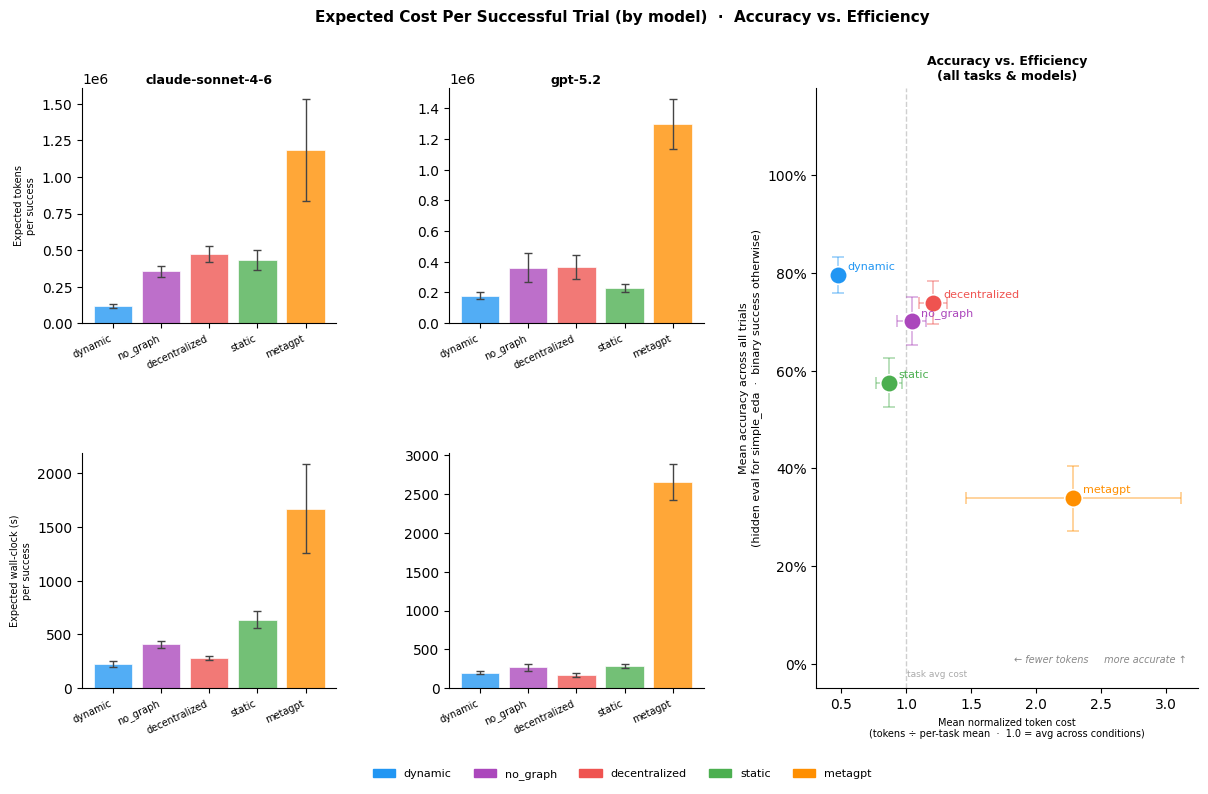

In [55]:
def plot_combined_cost_and_scatter(runs, hidden_runs, tasks,
                                   exclude_conditions=CONDITION_EXCLUDE_METRICS):
    HIDDEN_ACCURACY_TASKS = {"simple_eda", "textproc"}
    METRICS = [
        ("total_tokens",       "Expected tokens\nper success"),
        ("wall_clock_seconds", "Expected wall-clock (s)\nper success"),
    ]

    models = sorted(set(r["model"] for r in runs
                        if r["condition"] not in exclude_conditions))
    n_models = len(models)

    width_ratios = [1.0] * n_models + [1.5]
    fig = plt.figure(figsize=(4.2 * n_models + 6.0, len(METRICS) * 3.4 + 1.0))
    gs  = fig.add_gridspec(len(METRICS), n_models + 1,
                           width_ratios=width_ratios,
                           hspace=0.55, wspace=0.38)

    for ci, model in enumerate(models):
        model_runs = [r for r in runs if r["model"] == model
                      and r["condition"] not in exclude_conditions]
        model_conds = sorted(set(r["condition"] for r in model_runs),
                             key=lambda c: list(CONDITION_COLORS).index(c)
                             if c in CONDITION_COLORS else 99)

        for ri, (field, ylabel) in enumerate(METRICS):
            ax = fig.add_subplot(gs[ri, ci])
            groups, values, colors, sems = [], [], [], []

            for cond in model_conds:
                cond_runs = [r for r in model_runs if r["condition"] == cond]
                if not cond_runs:
                    continue
                pass_rate = sum(1 for r in cond_runs if r["success"]) / len(cond_runs)
                if pass_rate == 0:
                    continue
                success_vals = [r[field] for r in cond_runs
                                if r["success"] and r.get(field) is not None
                                and r[field] > 0]
                if not success_vals:
                    continue
                groups.append(cond)
                values.append(np.mean(success_vals) / pass_rate)
                sem = (np.std(success_vals, ddof=1) / np.sqrt(len(success_vals)) / pass_rate if len(success_vals) > 1 else 0.0)
                sems.append(sem)
                colors.append(CONDITION_COLORS.get(cond, "#888"))

            bars = ax.bar(range(len(groups)), values, color=colors, alpha=0.78,
                          edgecolor="white", linewidth=0.6, zorder=2,
                          yerr=sems, error_kw=dict(ecolor="#444", capsize=3, capthick=1, elinewidth=1, zorder=5))

            ax.set_xticks(range(len(groups)))
            ax.set_xticklabels(groups, fontsize=7, rotation=25, ha="right")
            ax.set_ylabel(ylabel if ci == 0 else "", fontsize=7)
            ax.set_title(model.split("/")[-1] if ri == 0 else "",
                         fontsize=9, fontweight="bold", pad=3)
            ax.spines[["top", "right"]].set_visible(False)

    ax_s = fig.add_subplot(gs[:, n_models])

    task_mean_tokens = {}
    for task in tasks:
        vals = [r["total_tokens"] for r in runs
                if r["task"] == task and r["success"]
                and r["condition"] not in exclude_conditions
                and r.get("total_tokens") is not None]
        if vals:
            task_mean_tokens[task] = np.mean(vals)

    all_conds = sorted(
        set(r["condition"] for r in runs if r["condition"] not in exclude_conditions),
        key=lambda c: list(CONDITION_COLORS).index(c) if c in CONDITION_COLORS else 99,
    )

    for cond in all_conds:
        acc_trials, ntok_trials = [], []
        for task in tasks:
            task_runs = [r for r in runs if r["task"] == task
                         and r["condition"] not in exclude_conditions]
            if task in HIDDEN_ACCURACY_TASKS and hidden_runs:
                h = [r for r in hidden_runs
                     if r["task"] == task and r["condition"] == cond
                     and r.get("hidden_pass_rate") is not None]
                acc_trials.extend(r["hidden_pass_rate"] for r in h)
            else:
                cm = [r for r in task_runs if r["condition"] == cond]
                acc_trials.extend(1.0 if r["success"] else 0.0 for r in cm)
            if task in task_mean_tokens:
                ntok_trials.extend(
                    r["total_tokens"] / task_mean_tokens[task]
                    for r in task_runs
                    if r["condition"] == cond and r["success"]
                    and r.get("total_tokens") is not None
                )
        if not acc_trials or not ntok_trials:
            continue

        mean_acc  = np.mean(acc_trials)
        mean_ntok = np.mean(ntok_trials)
        sem_acc   = np.std(acc_trials,  ddof=1) / np.sqrt(len(acc_trials))  if len(acc_trials)  > 1 else 0.0
        sem_ntok  = np.std(ntok_trials, ddof=1) / np.sqrt(len(ntok_trials)) if len(ntok_trials) > 1 else 0.0

        col = CONDITION_COLORS.get(cond, "#888")
        if sem_acc > 0 or sem_ntok > 0:
            ax_s.errorbar(mean_ntok, mean_acc, xerr=sem_ntok, yerr=sem_acc,
                          fmt="none", color=col, alpha=0.45,
                          capsize=4, capthick=1.2, elinewidth=1.2, zorder=3)
        ax_s.scatter(mean_ntok, mean_acc, color=col, marker="o", s=160,
                     zorder=4, edgecolors="white", linewidths=1.2)
        ax_s.annotate(cond, (mean_ntok, mean_acc), textcoords="offset points",
                      xytext=(7, 4), fontsize=8, color=col, zorder=5)

    ax_s.axvline(1.0, color="#bbb", lw=1, linestyle="--", alpha=0.7, zorder=1)
    ax_s.text(1.01, 0.02, "task avg cost", fontsize=6.5, color="#aaa",
              ha="left", transform=ax_s.get_xaxis_transform())
    ax_s.set_xlabel(
        "Mean normalized token cost\n"
        "(tokens ÷ per-task mean  ·  1.0 = avg across conditions)",
        fontsize=7,
    )
    ax_s.set_ylabel(
        "Mean accuracy across all trials\n"
        "(hidden eval for simple_eda  ·  binary success otherwise)",
        fontsize=8,
    )
    ax_s.set_ylim(-0.05, 1.18)
    ax_s.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax_s.spines[["top", "right"]].set_visible(False)
    ax_s.text(0.97, 0.04, "← fewer tokens     more accurate ↑",
              transform=ax_s.transAxes, fontsize=7, color="#888",
              ha="right", va="bottom", style="italic")
    ax_s.set_title("Accuracy vs. Efficiency\n(all tasks & models)",
                   fontsize=9, fontweight="bold")

    legend_patches = [
        mpatches.Patch(color=CONDITION_COLORS[c], label=c)
        for c in CONDITION_COLORS if c not in exclude_conditions
    ]
    fig.legend(handles=legend_patches, loc="lower center",
               ncol=len(legend_patches), fontsize=8, frameon=False,
               bbox_to_anchor=(0.5, -0.02))
    fig.suptitle(
        "Expected Cost Per Successful Trial (by model)  ·  Accuracy vs. Efficiency",
        fontsize=11, fontweight="bold",
    )
    plt.show()


plot_combined_cost_and_scatter(all_runs, hidden_runs, tasks,
                               exclude_conditions=CONDITION_EXCLUDE_METRICS)

In [57]:
def load_events(run_dir: Path) -> list[dict]:
    return [json.loads(l) for l in (run_dir / "events.jsonl").open()]


def build_agent_timeline(events: list[dict]) -> dict:
    dispatch_by_round, tests_by_round, tests_total = {}, {}, 0
    for e in events:
        r = e.get("round")
        if r is None:
            continue
        t = e["type"]
        if t == "round_dispatch":
            dispatch_by_round[r] = {"n_dispatched": e["n_dispatched"], "n_total": e["n_total"]}
        elif t == "run_tests":
            stdout = e.get("stdout", "")
            passed = total = 0
            for line in stdout.split("\n"):
                parts = line.split()
                for i, p in enumerate(parts):
                    tok = p.rstrip(",")
                    if tok == "passed" and i > 0:
                        try: passed = int(parts[i - 1])
                        except ValueError: pass
                    if tok == "failed" and i > 0:
                        try:
                            failed = int(parts[i - 1])
                            total  = max(total, passed + failed)
                        except ValueError: pass
            if total == 0:
                total = passed
            tests_total = max(tests_total, total)
            tests_by_round[r] = max(tests_by_round.get(r, 0), passed)

    rounds = sorted(dispatch_by_round.keys())
    return {
        "rounds":       rounds,
        "n_dispatched": [dispatch_by_round[r]["n_dispatched"] for r in rounds],
        "n_idle":       [dispatch_by_round[r]["n_total"] - dispatch_by_round[r]["n_dispatched"]
                         for r in rounds],
        "n_total":      [dispatch_by_round[r]["n_total"] for r in rounds],
        "tests_passed": [tests_by_round.get(r) for r in rounds],
        "tests_total":  tests_total,
    }


def compute_edit_metrics(events: list[dict]) -> dict:
    file_edit_history       = _dd(list)
    chars_by_round          = _dd(int)
    messages_per_agent      = _dd(int)
    message_chars_per_agent = _dd(int)
    edits_by_file_round     = _dd(list)

    for e in events:
        r = e.get("round", 0)
        t = e["type"]
        if t == "edit_file":
            agent   = e.get("agent", "unknown")
            path    = e.get("path", "")
            n_chars = e.get("n_chars", 0)
            file_edit_history[path].append((agent, r, n_chars))
            chars_by_round[r] += n_chars
            edits_by_file_round[(path, r)].append((agent, n_chars))
        elif t == "agent_reply":
            agent = e.get("agent", "")
            if agent and agent != "Lead":
                messages_per_agent[agent] += 1
                message_chars_per_agent[agent] += len(e.get("text", ""))

    cross_agent_overwrites = sum(
        1 for history in file_edit_history.values()
        for i in range(1, len(history)) if history[i][0] != history[i - 1][0]
    )

    concurrent_collisions, wasted_chars = [], 0
    for (path, r), edits in edits_by_file_round.items():
        distinct = list(dict.fromkeys(a for (a, _) in edits))
        if len(distinct) > 1:
            concurrent_collisions.append((path, r, distinct))
            for (_, n_chars) in edits[:-1]:
                wasted_chars += n_chars

    return {
        "cross_agent_overwrites":  cross_agent_overwrites,
        "n_concurrent_collisions": len(concurrent_collisions),
        "wasted_chars":            wasted_chars,
        "total_code_chars":        sum(n for h in file_edit_history.values() for (_, _, n) in h),
        "total_messages":          sum(messages_per_agent.values()),
        "total_message_chars":     sum(message_chars_per_agent.values()),
    }


def _enrich_runs_with_event_metrics(runs: list[dict], project_root: Path) -> list[dict]:
    NULL = {k: None for k in ("cross_agent_overwrites", "n_concurrent_collisions",
                               "wasted_chars", "total_code_chars",
                               "total_messages", "total_message_chars",
                               "_idle_rounds", "_idle_fracs")}

    cache_path = project_root / "experiments" / "event_metrics.json"
    cache = {}
    if cache_path.exists():
        with cache_path.open() as _f:
            cache = json.load(_f)

    enriched = []
    for row in runs:
        run_dir_rel = row.get("run_dir", "")
        if run_dir_rel in cache:
            m = cache[run_dir_rel]
            enriched.append({**row, **m})
            continue
        run_dir = Path(run_dir_rel)
        if not run_dir.is_absolute():
            run_dir = project_root / run_dir
        if not (run_dir / "events.jsonl").exists():
            enriched.append({**row, **NULL})
            continue
        evts  = load_events(run_dir)
        m     = compute_edit_metrics(evts)
        tl    = build_agent_timeline(evts)
        idle_fracs = [i / t if t > 0 else 0.0
                      for i, t in zip(tl["n_idle"], tl["n_total"])]
        enriched.append({
            **row,
            "cross_agent_overwrites":  m["cross_agent_overwrites"],
            "n_concurrent_collisions": m["n_concurrent_collisions"],
            "wasted_chars":            m["wasted_chars"],
            "total_code_chars":        m["total_code_chars"],
            "total_messages":          m["total_messages"],
            "total_message_chars":     m["total_message_chars"],
            "_idle_rounds":            tl["rounds"],
            "_idle_fracs":             idle_fracs,
        })
    return enriched


enriched_all_runs = _enrich_runs_with_event_metrics(all_runs, _ROOT)
n_with_events = sum(1 for r in enriched_all_runs if r.get("_idle_rounds") is not None)

In [58]:
def _strip_bars(ax, data: dict, colors: dict, ylabel: str, title: str, pct: bool = False):
    """Bar + strip chart: mean ± SEM bar with individual data points overlaid."""
    conds = list(data.keys())
    for i, cond in enumerate(conds):
        vals = np.array(data[cond], dtype=float)
        col  = colors.get(cond, "#888")
        mean = np.mean(vals)
        sem  = np.std(vals, ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0.0

        ax.bar(i, mean, color=col, alpha=0.65, edgecolor="white", linewidth=0.6,
               yerr=sem, error_kw=dict(ecolor="#444", capsize=3, capthick=1,
                                       elinewidth=1, zorder=5))

        jitter = np.random.default_rng(i).uniform(-0.15, 0.15, size=len(vals))
        ax.scatter(i + jitter, vals, color=col, s=18, alpha=0.75,
                   zorder=4, edgecolors="none")

    ax.set_xticks(range(len(conds)))
    ax.set_xticklabels(conds, fontsize=7, rotation=25, ha="right")
    ax.set_ylabel(ylabel, fontsize=7)
    if title:
        ax.set_title(title, fontsize=8, fontweight="bold", pad=3)
    ax.spines[["top", "right"]].set_visible(False)
    if pct:
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))

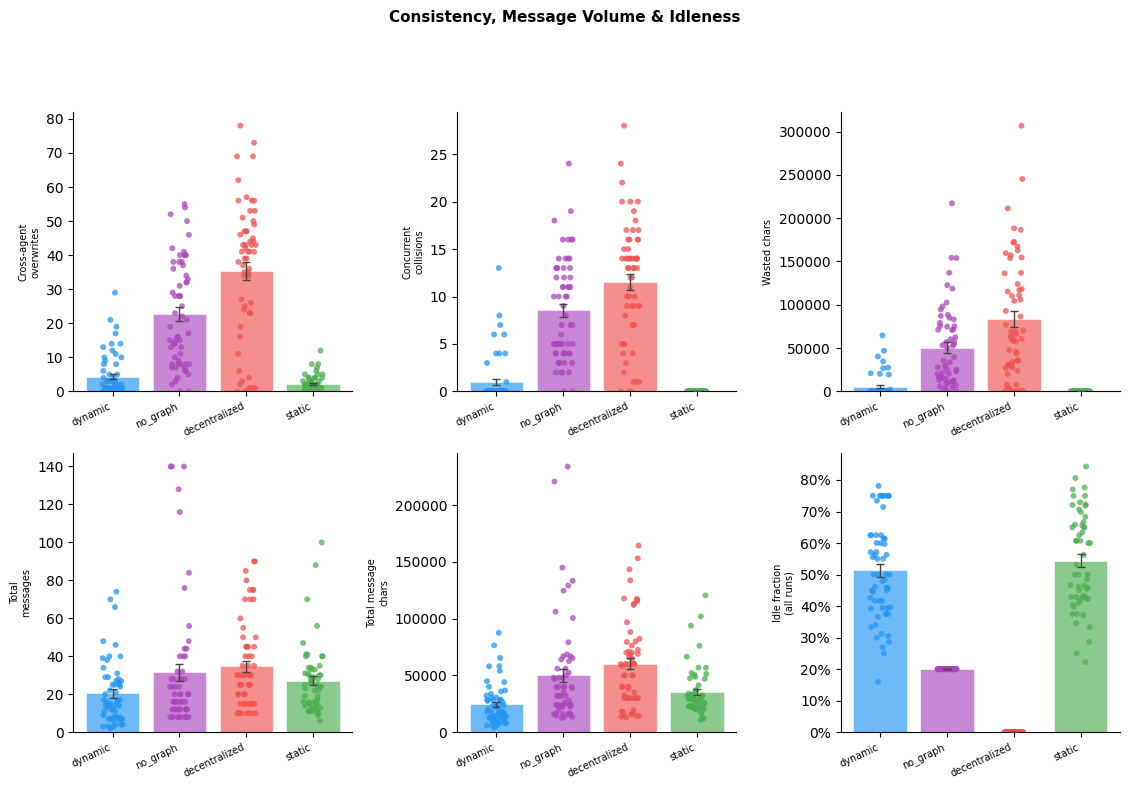

In [59]:
def plot_consistency_and_messages_combined(enriched_runs: list[dict],
                                            exclude_conditions=frozenset()):
    METRICS = [
        ("cross_agent_overwrites",  "Cross-agent\noverwrites",   False, set()),
        ("n_concurrent_collisions", "Concurrent\ncollisions",    False, set()),
        ("wasted_chars",            "Wasted chars",               False, set()),
        ("total_messages",          "Total\nmessages",           False, set()),
        ("total_message_chars",     "Total message\nchars",      False, set()),
        ("idle_fraction",           "Idle fraction\n(all runs)", True,  {"metagpt"}),
    ]
    filtered = [r for r in enriched_runs if r["condition"] not in exclude_conditions]
    all_conds = sorted(
        set(r["condition"] for r in filtered),
        key=lambda c: list(CONDITION_COLORS).index(c) if c in CONDITION_COLORS else 99,
    )

    n_cols = 3
    n_rows = 2
    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(3.8 * n_cols, 4.0 * n_rows),
                              squeeze=False)
    fig.suptitle(
        "Consistency, Message Volume & Idleness\n",
        fontsize=11, fontweight="bold",
    )

    for mi, (field, ylabel, pct, extra_excl) in enumerate(METRICS):
        ax = axes[mi // n_cols][mi % n_cols]
        data = {c: [r.get(field) for r in filtered
                    if r["condition"] == c and c not in extra_excl
                    and r.get(field) is not None]
                for c in all_conds}
        data = {c: v for c, v in data.items() if v}
        _strip_bars(ax, data, CONDITION_COLORS, ylabel, "", pct=pct)

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


plot_consistency_and_messages_combined(enriched_all_runs,
                                        exclude_conditions=CONDITION_EXCLUDE_METRICS)

## LATTE: Operator Usage & Task-Graph Evolution

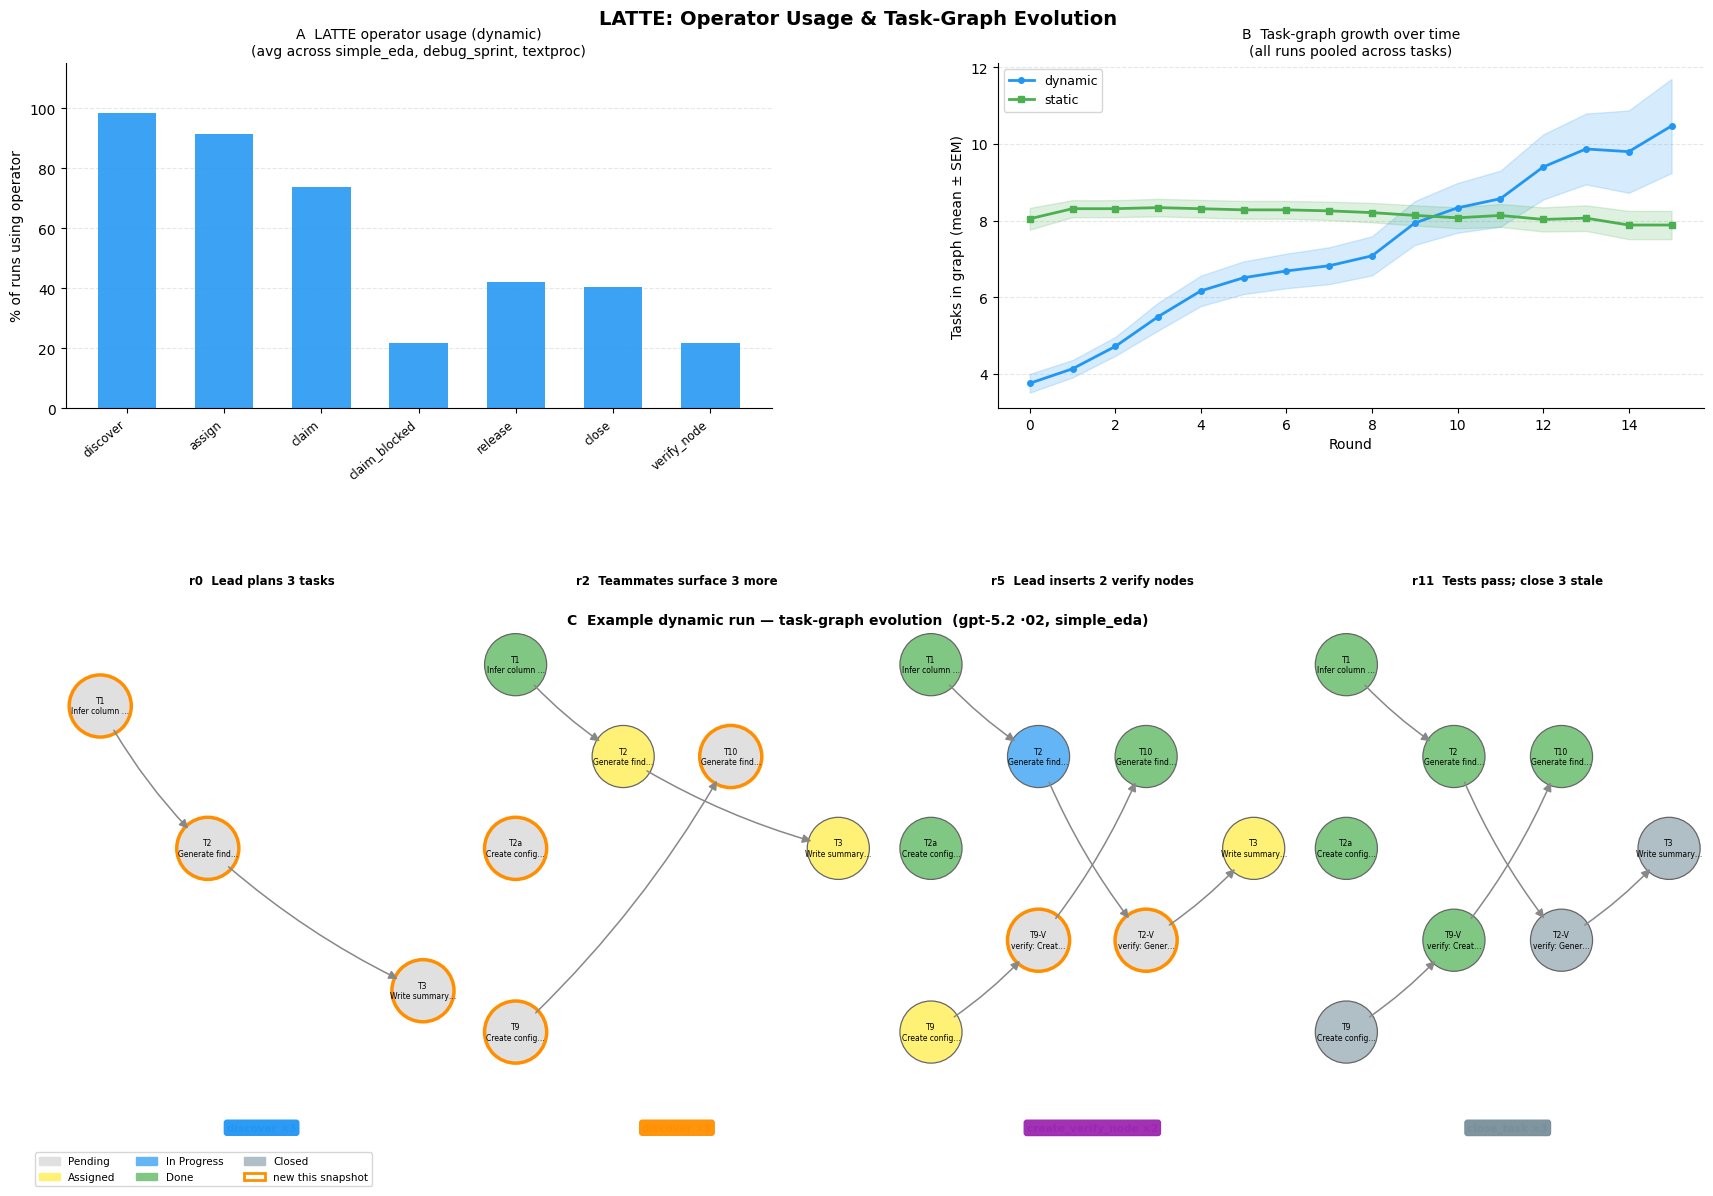

In [62]:
OPERATORS = [
    "discover_task", "assign_task", "claim_task", "release_task",
    "close_task", "create_verify_node", "synthesize",
    "claim_blocked", "discover_task_skipped",
]


def _condition(run_name):
    m = re.search(r'_(dynamic|static|no_graph|decentralized|fixed)_', run_name)
    if not m:
        return 'unknown'
    return 'static' if m.group(1) == 'fixed' else m.group(1)


def _hier_layout(nodes, edges):
    G = nx.DiGraph()
    G.add_nodes_from(nodes)
    G.add_edges_from(edges)
    depth = {}
    try:
        for node in nx.topological_sort(G):
            preds = list(G.predecessors(node))
            depth[node] = (max(depth[p] for p in preds) + 1) if preds else 0
    except nx.NetworkXUnfeasible:
        depth = {n: i for i, n in enumerate(nodes)}
    by_depth = defaultdict(list)
    for node, d in depth.items():
        by_depth[d].append(node)
    pos = {}
    for d, group in by_depth.items():
        for i, node in enumerate(sorted(group)):
            pos[node] = (d * 2.8, -(i - (len(group) - 1) / 2) * 2.2)
    return pos


_STATUS_COLOR = {
    "pending":     "#E0E0E0",
    "assigned":    "#FFF176",
    "in_progress": "#64B5F6",
    "done":        "#81C784",
    "closed":      "#B0BEC5",
}
_NODE_SIZE = 2000
_SHRINK    = 20


def _draw_snapshot(ax, snapshot, fixed_pos, new_node_ids, title, op_label, op_color):
    nodes = snapshot["nodes"]
    edges = snapshot["edges"]

    G = nx.DiGraph()
    G.add_nodes_from(nodes.keys())
    G.add_edges_from(edges)
    pos = {n: fixed_pos[n] for n in nodes if n in fixed_pos}

    node_list = [n for n in G.nodes() if n in pos]
    colors    = [_STATUS_COLOR.get(nodes[n]["status"], "#FFF") for n in node_list]
    ec_list   = ["#FF8F00" if n in new_node_ids else "#666" for n in node_list]
    lw_list   = [2.5       if n in new_node_ids else 0.9   for n in node_list]

    labels = {}
    for n, m in nodes.items():
        num   = n.replace("task-", "T").replace("-verify", "-V")
        short = m["title"].strip()
        if len(short) > 14:
            short = short[:13] + "\u2026"
        labels[n] = f"{num}\n{short}"

    nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=node_list,
                           node_color=colors, node_size=_NODE_SIZE,
                           linewidths=lw_list, edgecolors=ec_list)
    nx.draw_networkx_labels(G, pos, labels={n: labels[n] for n in node_list},
                            ax=ax, font_size=5.5)

    for u, v in G.edges():
        if u not in pos or v not in pos:
            continue
        ax.annotate("", xy=pos[v], xycoords="data",
                    xytext=pos[u], textcoords="data",
                    arrowprops=dict(arrowstyle="-|>", color="#888", lw=1.1,
                                   mutation_scale=13,
                                   connectionstyle="arc3,rad=0.08",
                                   shrinkA=_SHRINK, shrinkB=_SHRINK))

    if pos:
        xs = [x for x, y in pos.values()]
        ys = [y for x, y in pos.values()]
        ax.set_xlim(min(xs) - 0.9, max(xs) + 0.9)
        ax.set_ylim(min(ys) - 0.9, max(ys) + 0.9)

    ax.axis("off")
    ax.set_title(title, fontsize=8.5, fontweight="bold", pad=4)
    ax.text(0.5, -0.03, op_label, transform=ax.transAxes,
            ha="center", va="top", fontsize=7.5, color=op_color, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.25", fc=op_color + "22",
                      ec=op_color, lw=0.9, alpha=0.95))


# ── Load pre-computed data ────────────────────────────────────────────────────

_usage_path = _ROOT / "experiments" / "operator_usage.json"
_traj_path  = _ROOT / "experiments" / "task_trajectories.json"
_snap_path  = _ROOT / "experiments" / "example_run_snapshots.json"

with _usage_path.open() as f:
    usage_rates = json.load(f)

with _traj_path.open() as f:
    _trajs = json.load(f)
_dyn_rounds = _trajs["dynamic"]["rounds"]
_dyn_means  = _trajs["dynamic"]["means"]
_dyn_stds   = _trajs["dynamic"]["stds"]
_sta_rounds = _trajs["static"]["rounds"]
_sta_means  = _trajs["static"]["means"]
_sta_stds   = _trajs["static"]["stds"]

with _snap_path.open() as f:
    _raw_snaps = json.load(f)
_snapshots = {int(k): v for k, v in _raw_snaps.items()}

_final_snap = _snapshots[max(_snapshots)]
_fixed_pos  = _hier_layout(_final_snap["nodes"], _final_snap["edges"])

_SHOW_ROUNDS = [0, 2, 5, 11]
_PANEL_META  = {
    0:  ("r0  Lead plans 3 tasks",              "discover ×3",            "#2196F3"),
    2:  ("r2  Teammates surface 3 more",         "discover ×3",            "#FF8F00"),
    5:  ("r5  Lead inserts 2 verify nodes",      "create_verify_node ×2",  "#9C27B0"),
    11: ("r11  Tests pass; close 3 stale",       "close_task ×3",          "#78909C"),
}

fig = plt.figure(figsize=(18, 12))
fig.suptitle("LATTE: Operator Usage & Task-Graph Evolution",
             fontsize=14, fontweight="bold", y=0.995)
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.5], hspace=0.42, wspace=0.32,
                      left=0.06, right=0.97, top=0.95, bottom=0.08)
ax_ops  = fig.add_subplot(gs[0, 0])
ax_traj = fig.add_subplot(gs[0, 1])
gs_c    = gs[1, :].subgridspec(1, 4, wspace=0.06)
ax_c    = [fig.add_subplot(gs_c[0, i]) for i in range(4)]

_ops_ordered = [
    "discover_task", "assign_task", "claim_task", "claim_blocked",
    "release_task", "close_task", "create_verify_node",
]
_op_short_a = {
    "discover_task":      "discover",
    "assign_task":        "assign",
    "claim_task":         "claim",
    "claim_blocked":      "claim_blocked",
    "release_task":       "release",
    "close_task":         "close",
    "create_verify_node": "verify_node",
}
x = np.arange(len(_ops_ordered))
bars_dyn = [usage_rates["dynamic"].get(op, 0) * 100 for op in _ops_ordered]
bars = ax_ops.bar(x, bars_dyn, 0.6, color=CONDITION_COLORS["dynamic"], alpha=0.88)
ax_ops.set_xticks(x)
ax_ops.set_xticklabels([_op_short_a[o] for o in _ops_ordered],
                       rotation=40, ha="right", fontsize=8.5)
ax_ops.set_ylabel("% of runs using operator")
ax_ops.set_ylim(0, 115)
ax_ops.set_title("A  LATTE operator usage (dynamic)\n"
                 "(avg across simple_eda, debug_sprint, textproc)", fontsize=10)
ax_ops.spines[["top", "right"]].set_visible(False)
ax_ops.yaxis.grid(True, alpha=0.3, linestyle="--")
ax_ops.set_axisbelow(True)

ax_traj.plot(_dyn_rounds, _dyn_means, color=CONDITION_COLORS["dynamic"],
             lw=2, marker="o", ms=4, label="dynamic")
ax_traj.fill_between(_dyn_rounds,
                     [m - s for m, s in zip(_dyn_means, _dyn_stds)],
                     [m + s for m, s in zip(_dyn_means, _dyn_stds)],
                     alpha=0.18, color=CONDITION_COLORS["dynamic"])
ax_traj.plot(_sta_rounds, _sta_means, color=CONDITION_COLORS["static"],
             lw=2, marker="s", ms=4, label="static")
ax_traj.fill_between(_sta_rounds,
                     [m - s for m, s in zip(_sta_means, _sta_stds)],
                     [m + s for m, s in zip(_sta_means, _sta_stds)],
                     alpha=0.18, color=CONDITION_COLORS["static"])
ax_traj.set_xlabel("Round")
ax_traj.set_ylabel("Tasks in graph (mean ± SEM)")
ax_traj.set_title("B  Task-graph growth over time\n(all runs pooled across tasks)", fontsize=10)
ax_traj.legend(fontsize=9)
ax_traj.spines[["top", "right"]].set_visible(False)
ax_traj.yaxis.grid(True, alpha=0.3, linestyle="--")
ax_traj.set_axisbelow(True)

prev_node_ids = set()
for ax_i, r in zip(ax_c, _SHOW_ROUNDS):
    snap          = _snapshots.get(r, _snapshots[min(_snapshots)])
    curr_node_ids = set(snap["nodes"].keys())
    new_node_ids  = curr_node_ids - prev_node_ids
    title, op_label, op_color = _PANEL_META[r]
    _draw_snapshot(ax_i, snap, _fixed_pos, new_node_ids, title, op_label, op_color)
    prev_node_ids = curr_node_ids

_leg_patches = [mpatches.Patch(color=c, label=s.replace("_", " ").title())
                for s, c in _STATUS_COLOR.items()]
_new_patch   = mpatches.Patch(facecolor="white", edgecolor="#FF8F00",
                               linewidth=2, label="new this snapshot")
fig.legend(handles=_leg_patches + [_new_patch],
           loc="lower left", ncol=3, fontsize=7.5,
           frameon=True, bbox_to_anchor=(0.04, 0.01))

fig.text(0.5, 0.48, "C  Example dynamic run — task-graph evolution  (gpt-5.2 ·02, simple_eda)",
         ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.show()